# Fake vs. Real News Headline Classifier

Two approaches are built and compared on the same train/validation split:

1. **TF-IDF** (bag-of-words weighted features) + linear classifiers
2. **Word embeddings** (dense vectors) + classifiers

The better approach is then retrained on the full training set and used to
predict labels for `testing_data.csv`.

**Data format:** both files are tab-separated with no header: `label<TAB>headline`.
Training labels are `0` (fake) / `1` (real). Test labels are all placeholder `2`s
to be predicted.


In [1]:
import re
import time
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import lil_matrix, csr_matrix
import chardet

RANDOM_STATE = 42  # fixed seed -> same split every rerun, so results are comparable


## 1. Load the data

In [2]:
'''
Check the encoding
'''
# Method 1
with open("../dataset/training_data.csv", "rb") as f:
    print(f.read(20))

with open("../dataset/testing_data.csv", "rb") as f:
    print(f.read(20))

# Method 2
with open("../dataset/training_data.csv", "rb") as f:
    print(chardet.detect(f.read(100)))  # We could use a higher `f.read` value, but with 100 it's already enough in our case

with open("../dataset/testing_data.csv", "rb") as f:
    print(chardet.detect(f.read(100)))

b'\xef\xbb\xbf0\tdonald trump se'
b'\xef\xbb\xbf2\tcopycat muslim '
{'encoding': 'UTF-8-SIG', 'confidence': 1.0, 'language': 'en', 'mime_type': 'text/plain'}
{'encoding': 'UTF-8-SIG', 'confidence': 1.0, 'language': 'en', 'mime_type': 'text/plain'}


In [3]:
def load_data(path):
    """
    Files are tab-separated with NO header row: <label>\t<headline text>
    encoding='utf-8-sig' strips the leading BOM present in these files.
    """
    return pd.read_csv(
        path, sep="\t", header=None,names=["label", "text"],
        encoding="utf-8-sig", dtype={"text": str},
    )

train_df = load_data("../dataset/training_data.csv")
test_df = load_data("../dataset/testing_data.csv")
print(f"Training rows: {len(train_df)} \nTest rows: {len(test_df)} \n\n{train_df["label"].value_counts()}")


Training rows: 34152 
Test rows: 9984 

label
0    17572
1    16580
Name: count, dtype: int64


In [4]:
train_df.head()

,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


In [5]:
test_df.head()

,label,text
0,2,copycat muslim terrorist arrested with assault...
1,2,wow! chicago protester caught on camera admits...
2,2,germany's fdp look to fill schaeuble's big shoes
3,2,mi school sends welcome back packet warning ki...
4,2,u.n. seeks 'massive' aid boost amid rohingya '...


## 2. Clean the text

Headlines contain some mojibake (mis-decoded punctuation like `‚`, `™`). We strip everything down to plain letters/digits/spaces and lowercase.

In [6]:
# `re.compile` is used to build a regex pattern. Build it once now, use multiple times later
_CLEAN_RE = re.compile(r"[^a-z0-9\s]")  # Filters out everything that is not(^) a lowercase letter(a-z), a digit(0-9) and whitespace(\s)
_SPACE_RE = re.compile(r"\s+")  # Match one or more consecutive whitespaces(\s+). Will be used to collapse multiple spaces into one

def clean_text(text):
    if not isinstance(text, str):
        return ""  # guard against NaN/missing values reaching .lower()
    text = text.lower()  # Lowercase everything so words like `Apple` and `apple` are treated the same
    text = _CLEAN_RE.sub(" ", text)  # Replace everything that matches our regex with a single space.
    text = _SPACE_RE.sub(" ", text).strip()  # Collapse multiple spaces down to one, strip leading/trailing space
    return text

# Create a column with our cleaned text to preserve the original text
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

# Check for headlines that became an empty string after cleaning (e.g. a headline that was ONLY punctuation/symbols) — these would contribute a meaningless
# zero-length token list downstream. We check BOTH files for visibility, but only
# ever drop from train_df — test_df must keep every row, since each one needs a
# prediction in the final submission.
empty_train = (train_df["clean_text"] == "").sum()
empty_test = (test_df["clean_text"] == "").sum()
print(f"Empty clean_text after cleaning -> train: {empty_train}, test: {empty_test}")

train_df = train_df[train_df["clean_text"] != ""].reset_index(drop=True)

# Drop exact duplicate (clean_text, label) pairs on train only
before_dups = len(train_df)
train_df = train_df.drop_duplicates(subset=["clean_text", "label"]).reset_index(drop=True)
print(f"Dropped {before_dups - len(train_df)} duplicate training rows.")

# Identify and drop rows where the SAME cleaned headline appears with DIFFERENT labels — contradictory training examples that would only confuse the model.
label_counts = train_df.groupby("clean_text")["label"].nunique()
conflicting_texts = label_counts[label_counts > 1].index
num_conflicting_rows = train_df["clean_text"].isin(conflicting_texts).sum()
train_df = train_df[~train_df["clean_text"].isin(conflicting_texts)].reset_index(drop=True)
print(f"Dropped {num_conflicting_rows} conflicting rows across {len(conflicting_texts)} unique text snippets.")

# Create a column with tokens, needed for the word-embedding approach later
train_df["tokens"] = train_df["clean_text"].str.split()
test_df["tokens"] = test_df["clean_text"].str.split()

print(f"\nFinal training rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
assert len(test_df) == 9984, "test_df row count must never change — every row needs a prediction"

display(train_df.head(3))
display(test_df.head(3))

Empty clean_text after cleaning -> train: 0, test: 0
Dropped 1955 duplicate training rows.
Dropped 0 conflicting rows across 0 unique text snippets.

Final training rows: 32197
Test rows: 9984


,label,text,clean_text,tokens
0,0,donald trump sends out embarrassing new year‚s...,donald trump sends out embarrassing new year s...,"[donald, trump, sends, out, embarrassing, new,..."
1,0,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...,"[drunk, bragging, trump, staffer, started, rus..."
2,0,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes an internet joke ...,"[sheriff, david, clarke, becomes, an, internet..."


,label,text,clean_text,tokens
0,2,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrested with assault...,"[copycat, muslim, terrorist, arrested, with, a..."
1,2,wow! chicago protester caught on camera admits...,wow chicago protester caught on camera admits ...,"[wow, chicago, protester, caught, on, camera, ..."
2,2,germany's fdp look to fill schaeuble's big shoes,germany s fdp look to fill schaeuble s big shoes,"[germany, s, fdp, look, to, fill, schaeuble, s..."


In [7]:
# Shared train/validation split (same split reused for both approaches so the comparison is fair)
train_idx, val_idx = train_test_split(
    train_df.index, test_size=0.15, random_state=RANDOM_STATE,
    stratify=train_df["label"],  # keeps the same fake/real ratio in both splits, so a lucky/unlucky split doesn't skew validation scores
)

# Pull labels by index — train_idx/val_idx get reused later for the TF-IDF and embedding features, so text and label always stay paired
y_tr = train_df.loc[train_idx, "label"].astype(int).values
y_val = train_df.loc[val_idx, "label"].astype(int).values


## 3. Approach A — TF-IDF

TF-IDF weights each word (and word pair) by how distinctive it is to a headline,
relative to the whole corpus. It's a strong, fast baseline for short text.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Vectorizing
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,               # drop rare words (<2 headlines)
    max_df=0.9,             # drop overly common words (>90% of headlines)
    stop_words="english",   # drop filler words
    sublinear_tf=True,      # dampen repeated-word counts
)
X_tr_tfidf = tfidf.fit_transform(train_df.loc[train_idx, "clean_text"]) # fit + transform on train
X_val_tfidf = tfidf.transform(train_df.loc[val_idx, "clean_text"])      # transform only, no fit (avoid leakage)

# Training
model_configs = [
    # Linear
    ("Logistic Regression", "Linear", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("Linear SVM", "Linear", LinearSVC(random_state=RANDOM_STATE)),
    ("SGD Classifier", "Linear", SGDClassifier(random_state=RANDOM_STATE)),
    # Probabilistic
    ("Naive Bayes", "Probabilistic", MultinomialNB()),
    ("Complement NB", "Probabilistic", ComplementNB()),
    # Tree-based
    ("Random Forest", "Tree-based", RandomForestClassifier(random_state=RANDOM_STATE)),
    ("Gradient Boosting", "Tree-based", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ("XGBoost", "Tree-based", XGBClassifier(random_state=RANDOM_STATE)),
    # Neural net
    ("MLP Classifier", "Neural net", MLPClassifier(random_state=RANDOM_STATE)),
    # Distance-based
    ("KNN (Cosine)", "Distance-based", KNeighborsClassifier(n_neighbors=5, metric='cosine')),
    # kernel-based
    ("Kernel SVM (RBF)", "Kernel-based", SVC(kernel='rbf', random_state=RANDOM_STATE)),
    # Ensemble/Meta
    ("Voting Classifier", "Ensemble/Meta", VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ('nb', MultinomialNB()),
        ('rf', RandomForestClassifier(random_state=RANDOM_STATE))
    ],
    voting='hard'
    )),
    ("LightGBM", "Tree-based", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
    ("CatBoost", "Tree-based", CatBoostClassifier(random_state=RANDOM_STATE, verbose=0))
]

results_rows = []
tfidf_models = {}   # keep the fitted model objects separately, keyed by name

for name, family, model in model_configs:
    t0 = time.time()
    model.fit(X_tr_tfidf, y_tr)
    fit_time = time.time() - t0

    preds = model.predict(X_val_tfidf)
    acc, f1 = accuracy_score(y_val, preds), f1_score(y_val, preds)

    tfidf_models[name] = model

    print(f"{name:25s} [{family:15s}]  acc={acc:.4f}  f1={f1:.4f} fit_time={fit_time:.1f}s")

Logistic Regression       [Linear         ]  acc=0.9290  f1=0.9305 fit_time=0.1s
Linear SVM                [Linear         ]  acc=0.9346  f1=0.9356 fit_time=0.0s
SGD Classifier            [Linear         ]  acc=0.9344  f1=0.9361 fit_time=0.1s
Naive Bayes               [Probabilistic  ]  acc=0.9319  f1=0.9322 fit_time=0.0s
Complement NB             [Probabilistic  ]  acc=0.9315  f1=0.9317 fit_time=0.0s
Random Forest             [Tree-based     ]  acc=0.9083  f1=0.9095 fit_time=28.6s
Gradient Boosting         [Tree-based     ]  acc=0.8019  f1=0.8316 fit_time=8.2s
XGBoost                   [Tree-based     ]  acc=0.8725  f1=0.8828 fit_time=5.3s
MLP Classifier            [Neural net     ]  acc=0.9232  f1=0.9237 fit_time=429.8s
KNN (Cosine)              [Distance-based ]  acc=0.8731  f1=0.8768 fit_time=0.0s
Kernel SVM (RBF)          [Kernel-based   ]  acc=0.9375  f1=0.9389 fit_time=169.2s
Voting Classifier         [Ensemble/Meta  ]  acc=0.9329  f1=0.9340 fit_time=33.8s
LightGBM              

## 4. Approach B — Word embeddings

In [ ]:
# Build vocabulary (ignore very rare words)
counter = Counter()
for toks in train_df.loc[train_idx, "tokens"]:
    counter.update(toks)
vocab = [w for w, c in counter.items() if c >= 3]
word2id = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
print(f"Vocabulary size: {V}")

Vocabulary size: 8567


In [ ]:
# Build a word co-occurrence matrix (window of 4 words on each side)
window = 4
cooc = lil_matrix((V, V), dtype=np.float32)

for toks in train_df.loc[train_idx, "tokens"]:
    ids = [word2id[w] for w in toks if w in word2id]
    n = len(ids)
    for i in range(n):
        for j in range(max(0, i - window), min(n, i + window + 1)):
            if i == j:
                continue
            cooc[ids[i], ids[j]] += 1.0

cooc = cooc.tocsr()
print("Co-occurrence matrix built:", cooc.shape)


Co-occurrence matrix built: (8567, 8567)


In [ ]:
# Reweight with PPMI (Positive Pointwise Mutual Information):
# words that co-occur more than chance get a positive score, everything
# else is clipped to 0 -- this is what makes the vectors meaningful.
total = cooc.sum()
row_sums = np.array(cooc.sum(axis=1)).flatten()
col_sums = np.array(cooc.sum(axis=0)).flatten()

coo = cooc.tocoo()
pij = coo.data / total
pi = row_sums[coo.row] / total
pj = col_sums[coo.col] / total
vals = np.maximum(np.log(pij / (pi * pj) + 1e-12), 0.0)
ppmi = csr_matrix((vals, (coo.row, coo.col)), shape=cooc.shape)

# Reduce to 100 dense dimensions -> our word embeddings
svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
word_vecs = svd.fit_transform(ppmi)
norms = np.linalg.norm(word_vecs, axis=1, keepdims=True)
norms[norms == 0] = 1
word_vecs_n = word_vecs / norms
print("Word embedding matrix:", word_vecs_n.shape)


Word embedding matrix: (8567, 100)


In [ ]:
# A headline's embedding = the average of its words' embeddings
def doc_embedding(tokens):
    vecs = [word_vecs_n[word2id[w]] for w in tokens if w in word2id]
    if not vecs:
        return np.zeros(word_vecs_n.shape[1])
    return np.mean(vecs, axis=0)

X_tr_emb = np.vstack(train_df.loc[train_idx, "tokens"].apply(doc_embedding).values)
X_val_emb = np.vstack(train_df.loc[val_idx, "tokens"].apply(doc_embedding).values)

emb_results = {}
for name, model in [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Linear SVM", LinearSVC()),
    ("MLP (small neural net)", MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=RANDOM_STATE)),
]:
    model.fit(X_tr_emb, y_tr)
    preds = model.predict(X_val_emb)
    acc, f1 = accuracy_score(y_val, preds), f1_score(y_val, preds)
    emb_results[name] = (model, acc, f1)
    print(f"{name:25s}  acc={acc:.4f}  f1={f1:.4f}")


Logistic Regression        acc=0.9230  f1=0.9233
Linear SVM                 acc=0.9240  f1=0.9243
MLP (small neural net)     acc=0.9230  f1=0.9214


c:\Users\Victor\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


## 5. Compare both approaches

In [ ]:
all_results = {f"TF-IDF + {k}": v for k, v in tfidf_results.items()}
all_results.update({f"Embeddings + {k}": v for k, v in emb_results.items()})

comparison = pd.DataFrame(
    [(k, v[1], v[2]) for k, v in all_results.items()],
    columns=["Model", "Accuracy", "F1"],
).sort_values("F1", ascending=False).reset_index(drop=True)
comparison


,Model,Accuracy,F1
0,TF-IDF + Linear SVM,0.934576,0.935642
1,TF-IDF + Naive Bayes,0.931884,0.932151
2,TF-IDF + Logistic Regression,0.928986,0.930496
3,Embeddings + Linear SVM,0.924017,0.924345
4,Embeddings + Logistic Regression,0.922981,0.923299
5,Embeddings + MLP (small neural net),0.922981,0.921420


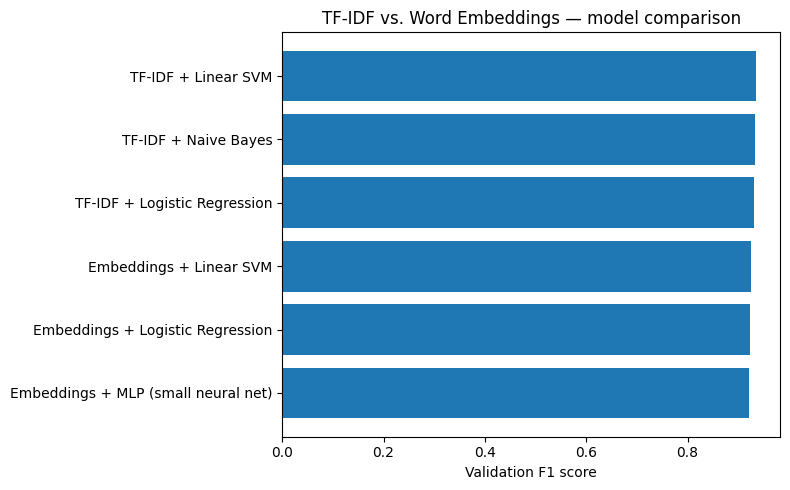

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(comparison["Model"], comparison["F1"])
plt.xlabel("Validation F1 score")
plt.title("TF-IDF vs. Word Embeddings — model comparison")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**What to expect / how to interpret this:** for short texts like news
headlines, TF-IDF (especially with bigrams) often matches or slightly beats
averaged word embeddings. Averaging word vectors throws away word order and
dilutes the signal from rare, highly distinctive words -- exactly the kind
of signal TF-IDF is built to preserve. Word embeddings tend to show a
bigger advantage on longer documents, or when using contextual embeddings
(like BERT) rather than static averaged ones. Whichever approach scores
best in *your* run is picked out automatically below.

## 6. Retrain the best model on all training data, and predict the test set

In [ ]:
best_name = comparison.iloc[0]["Model"]
print("Best model:", best_name)

use_embeddings = best_name.startswith("Embeddings")
sub_name = best_name.split(" + ", 1)[1]

model_lookup = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB(),
    "MLP (small neural net)": MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=RANDOM_STATE),
}
final_model = model_lookup[sub_name]


Best model: TF-IDF + Linear SVM


In [ ]:
if use_embeddings:
    # Rebuild vocab/co-occurrence/embeddings using ALL training data
    counter = Counter()
    for toks in train_df["tokens"]:
        counter.update(toks)
    vocab = [w for w, c in counter.items() if c >= 3]
    word2id = {w: i for i, w in enumerate(vocab)}
    V = len(vocab)

    cooc = lil_matrix((V, V), dtype=np.float32)
    for toks in train_df["tokens"]:
        ids = [word2id[w] for w in toks if w in word2id]
        n = len(ids)
        for i in range(n):
            for j in range(max(0, i - window), min(n, i + window + 1)):
                if i == j:
                    continue
                cooc[ids[i], ids[j]] += 1.0
    cooc = cooc.tocsr()

    total = cooc.sum()
    row_sums = np.array(cooc.sum(axis=1)).flatten()
    col_sums = np.array(cooc.sum(axis=0)).flatten()
    coo = cooc.tocoo()
    pij = coo.data / total
    pi = row_sums[coo.row] / total
    pj = col_sums[coo.col] / total
    vals = np.maximum(np.log(pij / (pi * pj) + 1e-12), 0.0)
    ppmi = csr_matrix((vals, (coo.row, coo.col)), shape=cooc.shape)

    svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
    word_vecs = svd.fit_transform(ppmi)
    norms = np.linalg.norm(word_vecs, axis=1, keepdims=True)
    norms[norms == 0] = 1
    word_vecs_n = word_vecs / norms

    X_full = np.vstack(train_df["tokens"].apply(doc_embedding).values)
    X_test = np.vstack(test_df["tokens"].apply(doc_embedding).values)
else:
    tfidf_full = TfidfVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.9,
        stop_words="english", sublinear_tf=True,
    )
    X_full = tfidf_full.fit_transform(train_df["clean_text"])
    X_test = tfidf_full.transform(test_df["clean_text"])

y_full = train_df["label"].astype(int).values
final_model.fit(X_full, y_full)
test_preds = final_model.predict(X_test)
print("Predicted label counts:")
print(pd.Series(test_preds).value_counts())


Predicted label counts:
1    5279
0    4705
Name: count, dtype: int64


## 7. Save predictions in the original file format

In [ ]:
output_df = pd.DataFrame({"label": test_preds, "text": test_df["text"]})

# Match the original file exactly: tab-separated, no header, UTF-8 BOM, CRLF line endings
output_df.to_csv(
    "testing_data_predictions.csv",
    sep="\t", header=False, index=False,
    encoding="utf-8-sig", lineterminator="\r\n",
)
print("Saved testing_data_predictions.csv")


Saved testing_data_predictions.csv


In [ ]:
testing_data_predictions = load_data('testing_data_predictions.csv')

In [ ]:
testing_data_predictions

,label,text
0,0,copycat muslim terrorist arrested with assault...
1,0,wow! chicago protester caught on camera admits...
2,1,germany's fdp look to fill schaeuble's big shoes
3,0,mi school sends welcome back packet warning ki...
4,1,u.n. seeks 'massive' aid boost amid rohingya '...
...,...,...
9979,0,boom! fox news leftist chris wallace attempts ...
9980,0,here it is: list of democrat hypocrites who vo...
9981,1,new fires ravage rohingya villages in northwes...
9982,0,meals on wheels shuts the lyin‚ lefties up wit...
